In [1]:
import matplotlib.pyplot as plt
import io
import requests
import xarray as xr

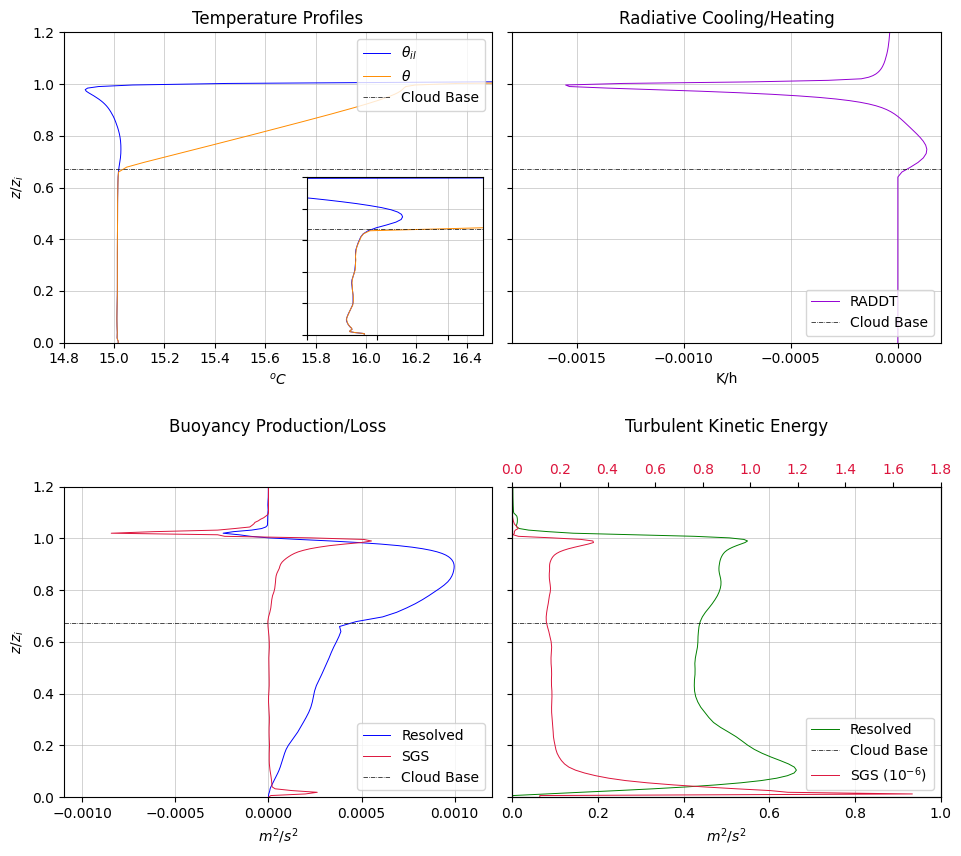

In [99]:
# --- Cloud base (last time step) ---
zi=833
c_base=560/zi

# --- Buoyancy/TKE data ---
url4="https://raw.githubusercontent.com/ChrisPhys97/Bachelor-Thesis/refs/heads/main/data/Buoyancy_TKE_data.nc"
response=requests.get(url4)
data=response.content
bf=xr.open_dataset(io.BytesIO(data),engine="h5netcdf")

fig,ax=plt.subplots(2,2,figsize=(9.5,8.5),constrained_layout={'hspace': 0.07, 'h_pad': 0.07})
ax[0,0].plot(bf.PTIL.values-273.15,bf.z.values/zi,linewidth=0.7,color="b",label=r"$\theta_{il}$")
ax[0,0].plot(bf.PT.values-273.15,bf.z.values/zi,color="darkorange",linewidth=0.7,label=r"$\theta$")
ax[0,1].plot(bf.RADDT.values,bf.z.values/zi,color="darkviolet",linewidth=0.7,label="RADDT")
ax[1,0].plot(bf.BFRES.values,bf.z.values/zi,linewidth=0.7,color="b",label="Resolved")
ax[1,0].plot(bf.BFSGS.values,bf.z.values/zi,linewidth=0.7,color="crimson",label="SGS")
ax[1,1].plot(bf.TKERES.values, bf.z.values/zi, linewidth=0.7, color="g", label="Resolved")
ax_twin = ax[1,1].twiny()
ax_twin.plot(bf.TKESGS.values/1e-6, bf.z.values/zi, linewidth=0.7, color="crimson", label="SGS $(10^{-6})$")
ax_twin.tick_params(axis='x', labelcolor='crimson')

subplot_titles = ["Temperature Profiles","Radiative Cooling/Heating","Buoyancy Production/Loss","Turbulent Kinetic Energy"]
xlabels=["${}^oC$","K/h","$m^2/s^2$","$m^2/s^2$"]

xlims = [[14.8,16.5],  [-0.0018,0.0002], [-0.0011,0.0012], [0,1] ]
xtick_settings = {ax[0,1]: [-0.0015,-0.001, -0.0005, 0],ax[1,0]: [-0.001, -0.0005, 0.0, 0.0005, 0.001]}

for i, a_single_ax in enumerate(ax.flat):
  row_idx = i // 2
  col_idx = i % 2
  a_single_ax.set_xlim(xlims[i])
  a_single_ax.set_ylim([0,1.2])
  a_single_ax.set_xlabel(xlabels[i])

  a_single_ax.set_title(subplot_titles[i], y=1.15 if i >= 2 else None)    # Set title, adjusting y for the bottom row
  a_single_ax.grid(True,linewidth=0.5,alpha=0.8)
  a_single_ax.axhline(y=c_base,linewidth=0.5,color="k",label="Cloud Base",linestyle="-.")

  if a_single_ax == ax[0,0]: a_single_ax.legend(loc="upper right")
  elif a_single_ax == ax[1,0] or a_single_ax == ax[0,1]: a_single_ax.legend(loc="lower right")

  if col_idx == 0: a_single_ax.set_ylabel("$z/z_i$")                      # First column, set ylables
  else: a_single_ax.set_yticklabels([])                                   # Second column, hide yticklabels

  if a_single_ax in xtick_settings: a_single_ax.set_xticks(xtick_settings[a_single_ax])

handles1, labels1 = ax[1,1].get_legend_handles_labels()
handles2, labels2 = ax_twin.get_legend_handles_labels()
ax_twin.set_xlim([0,1.8])
ax[1,1].legend(handles1 + handles2, labels1 + labels2, loc='lower right')

# --- Create an inset subplot for zooming potential temperature ---
inset_ax = fig.add_axes([0.317, 0.61, 0.185, 0.185])                      # [left, bottom, width, height] as fractions of figure width/height
inset_ax.plot(bf.PTIL.values-273.15,bf.z.values/zi,linewidth=0.7,color="b",label=r"$\theta_{il}$")
inset_ax.plot(bf.PT.values-273.15,bf.z.values/zi,color="darkorange",linewidth=0.7,label=r"$\theta$")
inset_ax.set_xlim([15.0, 15.05])
inset_ax.set_ylim([0,1])
inset_ax.grid(True,linewidth=0.5,alpha=0.8)
inset_ax.axhline(y=c_base,linewidth=0.5,color="k",label="Cloud Base",linestyle="-.")
inset_ax.set_yticklabels([])
inset_ax.set_xticklabels([])
plt.show()

## Results and Discussion

<div style="text-align: justify;
text-justify: inter-word; font-size: 17px;">

The shear-dominant case exhibits a well-mixed boundary layer below the cloud base, as shown by the temperature profiles. Both the potential temperature and the liquid water potential temperature are nearly identical and display an approximately zero vertical gradient within the mixed layer. However, within the cloud layer, the potential temperature increases more rapidly, reflecting the latent heat released during the phase changes of water vapor.

In contrast, the liquid water potential temperature accounts for the latent heat effects associated with phase changes and is therefore a more conservative thermodynamic variable. As a result, the sharp temperature inversion at the top of the atmospheric boundary layer (ABL), where the free atmosphere is reached, is more clearly represented by the liquid water potential temperature profile.

However, the liquid water potential temperature does not account for radiative heating and cooling processes. This effect is illustrated by the radiative heating/cooling profile. Near the cloud base, the system experiences weak radiative heating, whereas strong radiative cooling is observed near the top of the ABL. This behavior is reflected in the liquid water potential temperature profile, which is modified by radiative heating and cooling within the cloud layer.

The radiative heating near the cloud base results from the net infrared radiation flux (Stull, 1988), since the surface temperature is higher than the air temperature near the cloud base. Conversely, at the cloud top, the net infrared radiation flux is negative because the temperature of the upper atmosphere is lower than that of the cloud top, leading to substantial radiative cooling.

Another feature worth mentioning is the extremely small surface temperature inversion, followed by weak temperature fluctuations aloft, between approximately $15^\circ\mathrm{C}$ and $15.02^\circ\mathrm{C}$. These fluctuations indicate that the mixed layer is not mathematically perfectly homogeneous, and that small vertical gradients remain. These weak temperature inversions and fluctuations can trigger a non-zero SGS buoyancy production/loss, which appears as a local maximum near the surface in the third subplot.

In MIMICA, the SGS buoyancy term is parameterized through an eddy-diffusivity formulation:<br>

$
K_h \frac{g}{\theta_{00}}
\left[
\Delta \theta_l + 0.608 \theta_{00} \Delta q_t
\right].
$<br>

Therefore, even a very small resolved gradient near the lower boundary can generate a finite SGS buoyancy flux.

Within the mixed layer, where turbulent motions are characterized by relatively large eddies, the SGS buoyancy term remains close to zero, indicating that most of the buoyancy transport is explicitly resolved by the LES. In contrast, the resolved buoyancy production increases monotonically with height and reaches its maximum within the cloud layer, where turbulent mixing is enhanced by cloud processes and radiative effects.

Near the top of the ABL, the resolved buoyancy production decreases as the stable capping inversion and entrainment zone inhibit large turbulent motions. At the same time, the SGS buoyancy term reaches its maximum positive value, indicating that subgrid-scale mixing becomes increasingly important in this region, where the turbulent length scales approach the model resolution.

Dynamically, positive buoyancy production promotes turbulent motions by allowing relatively cold, dense air parcels to sink while warmer, lighter parcels rise, thereby converting potential energy into turbulent kinetic energy. Above the ABL top, however, both the resolved and SGS buoyancy terms become negative, indicating that the strong stable stratification suppresses turbulent motions and inhibits vertical mixing. In this region, buoyancy acts as a sink of turbulent kinetic energy, contributing to the maintenance of the capping inversion.

The TKE profile shows that the resolved component dominates throughout most of the boundary layer. A strong maximum appears near the surface, which is consistent with the shear-dominant setup and the enhanced friction velocity. Since the surface sensible and latent heat fluxes are zero, this near-surface TKE maximum is mainly mechanically produced by wind shear rather than by buoyancy forcing.

Above the surface layer, the resolved TKE decreases and remains relatively uniform through the mixed layer. This suggests that turbulence is efficiently redistributed vertically by large eddies. Within the cloud layer, the resolved TKE increases slightly again, likely due to cloud-top radiative cooling and entrainment effects. Near and above the ABL top, the resolved TKE rapidly decreases as the stable capping inversion suppresses vertical turbulent motions.

The SGS TKE is much smaller than the resolved component, as indicated by the $10^{-6}$ scaling in the plot. It is largest near the surface, where strong velocity gradients produce small-scale turbulence close to the lower boundary. A secondary SGS maximum also appears near the ABL top, where sharp thermodynamic and velocity gradients occur in the entrainment zone. This indicates that the SGS model mainly contributes in regions where the turbulent length scales become small: near the surface and near the inversion

</div>